# Simple Linear Regression

Predicting estimated salary by years of experience

*By: José Reyes*

In [2]:
#Dependencies 

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import t, f
import math

Data Loading

In [ ]:
data = pd.read_csv('./data/salaries.csv')

In [4]:
data = data[['YearsExperience', 'Salary']]

In [5]:
data.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


## Descriptive Analysis

In [6]:
round(data.describe(), 2)

,YearsExperience,Salary
count,30.00,30.00
mean,5.41,76004.00
std,2.84,27414.43
min,1.20,37732.00
25%,3.30,56721.75
50%,4.80,65238.00
75%,7.80,100545.75
max,10.60,122392.00


## Correlation Analysis

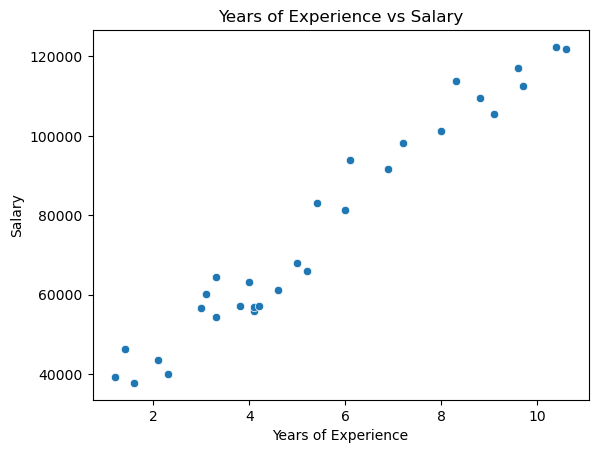

In [7]:
sns.scatterplot(x=data.columns[0], y=data.columns[1], data=data)
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

Positive correlation.

In [8]:
# Pearson correlation coefficient
correlation = np.corrcoef(data['YearsExperience'], data['Salary'])[0, 1]
print(f'Pearson correlation coefficient: {correlation:.2f}')

Pearson correlation coefficient: 0.98


In [9]:
# Same but pandas way
correlation_pandas = data.corr().iloc[0, 1]
print(f'Pearson correlation coefficient (pandas): {correlation_pandas:.2f}')

Pearson correlation coefficient (pandas): 0.98


The Pearson Correlation shows a STRONG positive correlation of 0.98

## Linear Regression

### Predicting Y (y-hat)

In [10]:
# Invoking Linear Regression and fitting X and Y
clf = LinearRegression()
#X = data[data.columns[0]].values.reshape(-1, 1) # Reshaping X to be a 2D array, as required by the LinearRegression model
X = [[round(i, 2)] for i in data['YearsExperience']] # Reshaping X to be a 2D array with a list comprehension, as required by the LinearRegression model
Y = data[data.columns[1]]
Y = data[data.columns[1]]

In [11]:
# This is just for demonstration purposes, to show the data in a tabular format before fitting the model
demonstrate = {'X': X, 'Y': Y}
pd.DataFrame(demonstrate).head()

,X,Y
0,[1.2],39344.0
1,[1.4],46206.0
2,[1.6],37732.0
3,[2.1],43526.0
4,[2.3],39892.0


Least Squares by fit and predict

In [12]:
# Building the model ecuation and making predictions
clf.fit(X, Y) # .fit() method is used to train the model, it finds the best fitting line for the data by minimizing the sum of squared errors between the predicted values and the actual values of Y
clf.predict(X) # .predict() method is used to make predictions using the trained model, it takes the input data (X) and returns the predicted values of Y based on the learned coefficients (b0 and b1)
b0 = round(clf.intercept_, 4) # Intercept
b1 = round(clf.coef_[0], 4) # Slope
print('Regression Ecuation: y-hat = ' + str(b0) + ' + ' + str(b1) + 'x') 

Regression Ecuation: y-hat = 24848.204 + 9449.9623x


Visualizing the curve

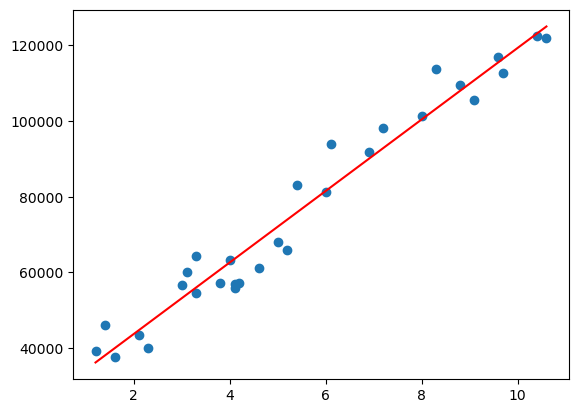

In [13]:
X_arr = np.asarray(X, dtype=float).flatten()  # Turning the lists of lists into a 1D array for plotting
y1 = b0 + b1*X_arr # Using the ecuation of the line to get the corresponding Y values for each X value, to plot the regression line
plt.scatter(X,Y) # Plotting the original data points
plt.plot(X,y1,c='r')   # Plotting the regression line, using the same X values and the corresponding Y values obtained from the ecuation of the line
plt.show()

The Regression line is near each observation point

### Fit Quality Measures.

#### SSE

In [14]:
# Turning Y into a numpy 1D array for the next calculations
Y_arr = np.asarray(Y, dtype=float).flatten() # Flattening the list of values into a simple vector, If we don't use flatten(), Y_arr would be a 2D array with one column, which is not what we want for the calculations of SST, SSE, and SSR. Causing SSE to be huge and SSR to be negative, which is not correct. By using flatten(), we get a 1D array of Y values, which allows us to correctly calculate the sums of squares and the R-squared value.

In [15]:
SSE = ((Y_arr - (b0 + b1 * X_arr)) ** 2).sum() # Sum of Squared Errors
print(f'Sum of Squared Errors (SSE): {SSE:.2f}')

Sum of Squared Errors (SSE): 938128551.67


#### SST

In [16]:
SST = ((Y_arr - Y_arr.mean())**2).sum() # Total Sum of Squares
print(f'Total Sum of Squares (SST): {SST:.2f}')

Total Sum of Squares (SST): 21794977852.00


#### SSR

In [17]:
SSR = round(SST, 3) - round(SSE, 3) # Regression Sum of Squares
print(f'Regression Sum of Squares (SSR): {SSR:.2f}')

Regression Sum of Squares (SSR): 20856849300.33


In [18]:
# Confirming that SST = SSR + SSE
if round(SST, 3) == round(SSR + SSE, 3):
    print('SST is equal to SSR + SSE, the calculations are correct.')
else:
    print('SST is NOT equal to SSR + SSE, there might be an error in the calculations.')

SST is equal to SSR + SSE, the calculations are correct.


#### R-Squared

In [19]:
# Calculating R-squared
R_squared = SSR / SST
print(f'R-squared: {R_squared:.4f}')

R-squared: 0.9570


In [20]:
# Confirming R-Squared with Pearson correlation coefficient
if round(R_squared, 4) == round(correlation**2, 4):
    print('R-squared is equal to the square of the Pearson correlation coefficient, the calculations are correct.')
    print("Inferential Statistics are like magic.")
else:
    print('R-squared is NOT equal to the square of the Pearson correlation coefficient, there might be an error in the calculations.')

R-squared is equal to the square of the Pearson correlation coefficient, the calculations are correct.
Inferential Statistics are like magic.


The model explains 95.70% of the data variability (strong model).

#### Correlation Coefficient

In [21]:
# Calculating Coefficient of Correlation
sign = 1 if b1 > 0 else -1 # Determining the sign of the correlation based on the slope of the regression line
correlation_coefficient = sign * math.sqrt(R_squared) # Calculating the coefficient of correlation, "sign" helps us to determine if the correlation is positive or negative based on the slope of the regression line, since "math.sqrt(R_squared)" (a square root) always returns a positive value, we need to multiply it by the sign to get the correct sign of the correlation coefficient.
print(f'Coefficient of Correlation: {correlation_coefficient:.4f}')

Coefficient of Correlation: 0.9782


The model's coefficient of correlation (0.9782) explains that every observation point/dot is very close from the regression line. An almost-perfect regression line.

### Conclusions about the expected y value linear regression

$$\hat{y} = 24848.204 + 9449.9623x$$

The y-hat equation shows a **R-squared** value of *0.9570*, which is translated to **95.70%** of efficiency predicting data variability of the dependent variable. 

**Coefficient of Correlation** of *0.9782* shows that the total of observations of the model are very close to the regression line. Meaning that the model predictions are very close to the reality of data.

## Significance Tests / Hypothesis Tests.

### T & F tests.

T = *Test used to know if every single variable works by itself (i.e Evaluating every single soccer player from a team), this helps in defining the importance of a variable compared to the whole model*

F = *Evaluates if the group of all dependent variables (x) support the (y) variable to show that a model can overcome randomness*

By statistical laws in Simple Regression, T and F will return the same p-value. Because evaluating a single variable equals to evaluating the entire team (with T test, a single variable equals the 100% of the model, F test is the same variable being tested with the rest of the model). Mathematically explained, F value is the same as T squared: ($F = t^2$)

#### Mean Squared Error for Simple Regression (MSE)

The "error" is the distance between our (y) real value and the y-hat value.

$$MSE = \frac{\sum (y_i - \hat{y}_i)^2}{n - 2}$$

$\sum (y_i - \hat{y}_i)^2$: Is our Error Sum of Squares (SSE).

$n - 2$: Is our liberty degree, this is explained as "To calculate SSE, it is necessary to estimate two parameters, 𝛽0 and 𝛽1"

In [22]:
deg = 2
MSE = SSE / (X_arr.size - deg)
print(f'Mean Squared Error (MSE): {MSE:.2f}')

Mean Squared Error (MSE): 33504591.13


*The MSE shows a high variance of 33504591.13 squared dollars (squared dollars doesn't exist, but that's the reason why the number is huge, because is squared)*

#### Standard Error of Estimate (SEE)

This calculation brings MSE back to earth. This is the "Residual standard deviation", explains how far the regression data points (in the graphic) are from the regression line (y-hat).

$$SEE = \sqrt{SSE}$$

In [23]:
SEE = math.sqrt(MSE)
print(f'Standard Error of the Estimate (SEE): {SEE:.2f}')

Standard Error of the Estimate (SEE): 5788.32


*The standard deviation of every value in our model is 5788.32 dollars, which means every simple regression value is 5788.32 dollars far from what the regression line predicts*

#### Hypothesis test : P-value for T value.

*"If y and x are linear, then B01 shouldn't be 0"*. This is our Alternate Hypothesis

$$H_0: \beta_1 = 0$$

Using the next formula, we can test the B1 slope.

$$t = \frac{b_1 - \beta_1}{s_{b_1}}$$

*In some places, courses or resources, the formula could not write or miss the B1 substraction, because most of the null hypotheses nullifies the B1 value to 0 like you saw above, but for a mathematician is important to explain why sometimes this value is missing*

$b_1$ : The slope value.

$\beta_1$ : Assumed hypothesis value (0 for this case)

$s_{b_1}$: Standard Error of the slope.

To calculate the Slope's Standard Error, we need this formula.

$$s_{b_1} = \frac{s}{\sqrt{\sum (x_i - \bar{x})^2}}$$

For the "S" value, equals to the residual standard deviation. In other words, the same value as SSE.

$$\text{SEE} = S = s_e = \sqrt{MSE} = \sqrt{\frac{\sum(y - \hat{y})^2}{n-2}}$$

In [24]:
S = SEE

In [25]:
# 1. Calculating Sb1
sb1 = S / math.sqrt((X_arr**2).sum() - X_arr.size * X_arr.mean()**2)
print(f'Standard error of the slope (Sb1): {sb1:.4f}')

Standard error of the slope (Sb1): 378.7546


In [26]:
# Calculating T value for the slope
value_t = round(b1 / sb1, 2)
print(f'T-value for the slope: {value_t}')

T-value for the slope: 24.95


In [27]:
# Using Scipy to calculate the p-value for the slope
degrees_of_freedom = X_arr.size - 2 # Subtract 2 for intercept and slope
t_p_value = t.sf(value_t, degrees_of_freedom) * 2 # Multiply by 2 for two-tailed test (Student's T distribution)
print(f'P-value for the slope: {t_p_value}')

P-value for the slope: 1.1431839767191605e-20


In [28]:
# validating p-value is valid with 0.05 significance level
if t_p_value < 0.05:
    print('The slope is statistically significant at the 0.05 significance level.')
else:
    print('The slope is NOT statistically significant at the 0.05 significance level.')

The slope is statistically significant at the 0.05 significance level.


#### Hypothesis test: P-value for F value.

F value formula is simplier...

$$F = \frac{MSR}{MSE}$$

We already have our Mean Squared Error (MSE) value calculated.

To calculate Mean Square Regression, we use this formula.

$$MSR =\frac{SSR}{k}$$

Where "K" is our degree of freedom, in this case, our regression degree of freedom equals to the number of variables being tested, so it's equal to 1.

In [29]:
# calculating F-value for the overall regression model
rdf = 1 # Regression degrees of freedom, which is the number of independent variables in the model (in this case, we have only one independent variable, "YearsExperience")
MSR = SSR / rdf # Mean Square Regression, a variable which we will use later on.
value_f = round(MSR / MSE, 1)
print(f'F-value for the overall regression model: {value_f}')

F-value for the overall regression model: 622.5


In [30]:
# Calculating p-value for F value with scipy
f_p_value = f.sf(value_f, rdf, degrees_of_freedom) # Using the survival function (sf) to calculate the p-value for the F-value, with 1 degree of freedom for the regression and (n - 2) degrees of freedom for the error
print(f'P-value for the overall regression model: {f_p_value}')

P-value for the overall regression model: 1.1432455789791036e-20


In [31]:
# Validating the overall regression model with a significance level of 0.05
if f_p_value < 0.05:
    print('The overall regression model is statistically significant at the 0.05 significance level.')
else:
    print('The overall regression model is NOT statistically significant at the 0.05 significance level.')

The overall regression model is statistically significant at the 0.05 significance level.


Remember when I said... 

$$F = t^2$$

In [32]:
# Comparing If F value equals to T value squared
if round(value_f, 1) == round(value_t**2, 1):
    print('The F-value is equal to the T-value squared, the calculations are correct.')
else:
    print('The F-value is NOT equal to the T-value squared, there might be an error in the calculations.')


The F-value is equal to the T-value squared, the calculations are correct.


*Once again, Statistics are like magic.*

### ANOVA Table.

In [33]:
ANOVA = pd.DataFrame({
    'Source of Variation': pd.Series(['Regression', 'Error', 'Total'], index=[0, 1, 2]),
    'Sum of Squares': pd.Series([SSR, SSE, SST], index=[0, 1, 2]),
    'Degrees of Freedom': pd.Series([rdf, degrees_of_freedom, X_arr.size - 1], index=[0, 1, 2]),
    'Mean Square': pd.Series([MSR, MSE], index=[0, 1]),
    'F': pd.Series([value_f], index=[0]),
    "P-Value": pd.Series([f_p_value], index=[0]) # Adding the p-value for the overall regression model to the ANOVA table
    })

In [34]:
ANOVA

,Source of Variation,Sum of Squares,Degrees of Freedom,Mean Square,F,P-Value
0,Regression,2.085685e+10,1,2.085685e+10,622.5,1.143246e-20
1,Error,9.381286e+08,28,3.350459e+07,NaN,NaN
2,Total,2.179498e+10,29,NaN,NaN,NaN


an ANOVA table is like the executive report to sell your model.

#### A summary from what we got and conclude by now...

*When using the simple linear regression model, an assumption is made about the relationship between x and y. You then use the least squares method to obtain an estimated simple linear regression equation. If there is a significant relationship between x and y, and if the coefficient of determination indicates that the fit is good, the estimated regression equation is useful for making estimates and predictions.*

## Model Validation

### Point Estimation

involves using sample data to calculate a single, specific value (a "point") that serves as the best guess for unknown population parameters.

$$\hat{y} = 24848.204 + 9449.9623(5)$$

Estimating x value of "5" to avoid extrapolation (The model assigns an overestimated value due to a x value above the range)

In [35]:
x = 5
pe = round(b0 + b1*x, 4)

In [36]:
print(f"Point Estimation of the Linear Regression when X = {x} : {pe}")

Point Estimation of the Linear Regression when X = 5 : 72098.0155


### Invertal Estimation

#### Trust Interval

The Trust Estimation Interval is the range where the real value is placed in for a single value of X. It's used to estimate the mean of a singe x value.

Range Estimation (for mean) formula:

$$\hat{y} \pm t_{\alpha/2} \cdot s \sqrt{\frac{1}{n} + \frac{(x_p - \bar{x})^2}{\sum(x_i - \bar{x})^2}}$$

Where:

- ($t_{\alpha/2}$) equals the number of deviations you use for your trust range (usually 95%).
- ($s$) equals the **SEE (Standard Error of Estimate)** value.
- $\frac{1}{n}$ equals to 1 divided by your total of observations. The more observations you have, the error would be less.
- $\frac{(x_p - \bar{x})^2}{\sum(x_i - \bar{x})^2}$ is the distance between your predicted value ($x_p$) and the mean of your original data ($\bar{x}$).

Using the "for mean" formula instead of the "single value" formula is because, we're answering this question...

**_What's the mean extimated salary for people with 5 years of experience?_**

In [37]:
# Using math and scipy to calculate the Trust Interval.

ta2 = round(t.isf(0.025, X_arr.size - 2), 3) # Using inverse survival function of T-Student to find T value of 95% (leaving 0.025 in the upper tail) and n-2 grades of liberty
sum_xi2_nxm2 = (X_arr**2).sum() - X_arr.size * X_arr.mean()**2  # Calculating the total variability of X values.
y_sum_subs_ti = round(ta2 * S * math.sqrt( 1 / X_arr.size + (x - X_arr.mean())**2 / sum_xi2_nxm2), 4)  # Calculating th entire formula.

## Interval Results ##
print(pe, '-', y_sum_subs_ti)
print(pe, '+', y_sum_subs_ti)
print(f"Trust Interval: ", round(pe - y_sum_subs_ti, 3), ' to ', round(pe + y_sum_subs_ti, 4))

72098.0155 - 2187.9391
72098.0155 + 2187.9391
Trust Interval:  69910.076  to  74285.9546


We have 95% of trust that the mean salary of every professional with 5 years of experience falls under this salary range...

#### Prediction Interval

Trust Estimation is used to calculate the mean of a group, the Prediction Interval calculates the single value of a single individual.

$$E_p = \hat{y} \pm t_{\alpha/2} \cdot s \sqrt{\mathbf{1} + \frac{1}{n} + \frac{(x_p - \bar{x})^2}{\sum(x_i - \bar{x})^2}}$$

As you might see, the formula is quite the same as the Trust Interval. Adding a "1" in the beginning of the square root. This is due to the "individual variability".

In [38]:
# Calculating the Prediction Interval

y_sum_subs_pi = round(ta2 * S * math.sqrt( 1 + 1 / X_arr.size + (x - X_arr.mean())**2 / sum_xi2_nxm2), 4)

## Interval Results ##
print(pe, '-', y_sum_subs_pi)
print(pe, '+', y_sum_subs_pi)
print(f"Prediction Interval: ", round(pe - y_sum_subs_pi, 3), ' to ', round(pe + y_sum_subs_pi, 4))


72098.0155 - 12054.6886
72098.0155 + 12054.6886
Prediction Interval:  60043.327  to  84152.7041


Using this formula, we're ansering this question...

**_If you're hiring a specific person with that level of experience, their salary could fall anywhere within this range._**

### Residual Analysis.

#### Residual vs. Predictor (or "x") plot

Text(0.5, 1.0, 'Residuals Plot')

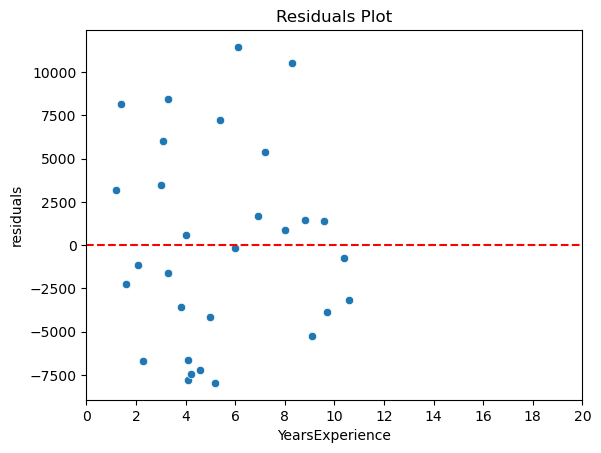

In [46]:
# Residuals plot

residuals = Y_arr -  (b0 + b1 * X_arr) # Calculating the residuals, which are the differences between the actual Y values and the predicted Y values from the regression line. This is done by subtracting the predicted Y values (b0 + b1 * X_arr) from the actual Y values (Y_arr).
data["residuals"] = Y_arr - (b0 + b1 * X_arr) # Adding the residuals to the data_residuals DataFrame, which will be used for plotting the residuals plot. This is done by creating a new column called "residuals" in the data_residuals DataFrame and assigning the calculated residuals to that column.
g = sns.scatterplot(data=data, x=data.columns[0], y='residuals') # Plotting the residuals plot using seaborn's scatterplot function, with the original X values on the x-axis and the residuals on the y-axis.
plt.xticks([0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]) # Setting the x-ticks to be at specific intervals for better visualization of the residuals plot.
plt.axhline(0, color='red', linestyle='--') # Adding a horizontal line at y=0 to help visualize how the residuals are distributed around the regression line. This line represents the ideal case where all residuals would be zero, indicating a perfect fit of the model to the data.
plt.title('Residuals Plot') # Adding a title to the plot for better understanding of what

The assumption of linearity appears to hold true. The relationship between years of experience and salary does indeed follow a straight line.

### Percentile Sample.

Text(0.5, 1.0, 'Cumulative Distribution of Residuals (Normal Distribution)')

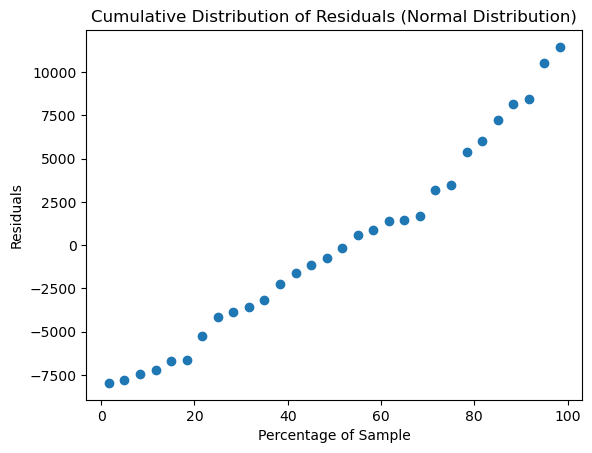

In [60]:
# Cumulative Distribution Curve


inc = 100 / X_arr.size
#y_ord = Y.sort_values() # Sorting the Y values in ascending order, which will be used for plotting the cumulative distribution of the residuals.
res_ord = data['residuals'].sort_values() # Sorting the residuals in ascending order, which will be used for plotting the cumulative distribution of the residuals.
perc_samp = np.arange(inc / 2, 101, inc) # Creating an array of percentage values from 0 to 100 with a step of "inc", which will be used for plotting the cumulative distribution of the residuals
plt.scatter(perc_samp, res_ord) # Plotting the cumulative distribution of the residuals using a scatter plot, with the sorted Y values on the x-axis and the corresponding percentage values on the y-axis
plt.xlabel('Percentage of Sample') # Adding label to the x-axis for better understanding of the plot
plt.ylabel('Residuals') # Adding label to the y-axis for better understanding of the plot
plt.title('Cumulative Distribution of Residuals (Normal Distribution)') # Adding a title to the plot for better understanding

The chart shows a fairly clear diagonal trend, which is a very good sign.

The salary model based on years of experience (from 1.2 to 10.6 years) is **statistically valid**. The errors are sufficiently normally distributed, and there are no extreme outliers that undermine the business logic.